In [ ]:
import os

os.listdir("/content")


['.config', 'hnd_female_csv2.zip', 'sample_data']

In [ ]:
import zipfile
import os

zip_path = "/content/hnd_female_csv2.zip"
extract_path = "/content/hundred_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
os.listdir(extract_path)


['1252733_info.csv',
 '1252705.csv',
 '1417855_info.csv',
 '1299152_info.csv',
 '1471052.csv',
 '1355604.csv',
 '1299160.csv',
 '1471040_info.csv',
 '1417845.csv',
 '1355599_info.csv',
 '1355601_info.csv',
 '1471041_info.csv',
 '1417824.csv',
 '1252731_info.csv',
 '1299169_info.csv',
 '1417830.csv',
 '1355591_info.csv',
 '1355596_info.csv',
 '1417846.csv',
 '1355583.csv',
 '1252730.csv',
 '1417856_info.csv',
 '1471049.csv',
 '1252714.csv',
 '1471046.csv',
 '1299159_info.csv',
 '1299170.csv',
 '1252723_info.csv',
 '1417836_info.csv',
 '1417832_info.csv',
 '1355603.csv',
 '1252710.csv',
 '1471041.csv',
 '1417846_info.csv',
 '1417851_info.csv',
 '1471042.csv',
 '1417856.csv',
 '1355602.csv',
 '1252720.csv',
 '1252726_info.csv',
 '1471054_info.csv',
 '1299155_info.csv',
 '1417849.csv',
 '1355590.csv',
 '1471066.csv',
 '1417833_info.csv',
 '1355593.csv',
 '1471038_info.csv',
 '1299160_info.csv',
 '1471055.csv',
 '1471050.csv',
 '1252717.csv',
 '1417841_info.csv',
 '1471060_info.csv',
 '1355

In [ ]:
import pandas as pd

all_matches = []
bad_files = []

required_cols = {
    "ball",
    "innings",
    "striker",
    "runs_off_bat",
    "batting_team"
}

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            try:
                df = pd.read_csv(file_path)

                # validate match ball-by-ball structure
                if required_cols.issubset(df.columns):
                    df["match_file"] = file
                    all_matches.append(df)
                else:
                    bad_files.append(file)

            except Exception:
                bad_files.append(file)


In [ ]:
tournament_df = pd.concat(all_matches, ignore_index=True)

print("Total match files loaded:", tournament_df["match_file"].nunique())
print("Total balls in tournament:", tournament_df.shape[0])


Total match files loaded: 156
Total balls in tournament: 54216


In [ ]:
tournament_df.columns


Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'match_file'],
      dtype='object')

In [ ]:
tournament_df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,match_file
0,1252705,2021,2021-07-25,"Old Trafford, Manchester",1,0.1,Birmingham Phoenix,Manchester Originals,EA Burns,Shafali Verma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252705.csv
1,1252705,2021,2021-07-25,"Old Trafford, Manchester",1,0.2,Birmingham Phoenix,Manchester Originals,Shafali Verma,EA Burns,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252705.csv
2,1252705,2021,2021-07-25,"Old Trafford, Manchester",1,0.3,Birmingham Phoenix,Manchester Originals,Shafali Verma,EA Burns,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252705.csv
3,1252705,2021,2021-07-25,"Old Trafford, Manchester",1,0.4,Birmingham Phoenix,Manchester Originals,EA Burns,Shafali Verma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252705.csv
4,1252705,2021,2021-07-25,"Old Trafford, Manchester",1,0.5,Birmingham Phoenix,Manchester Originals,EA Burns,Shafali Verma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1252705.csv


In [ ]:
tournament_df.tail()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,match_file
54211,1355589,2023,2023-08-13,"Headingley, Leeds",2,15.1,Manchester Originals,Northern Superchargers,EL Lamb,FMK Morris,...,NaN,NaN,NaN,NaN,NaN,caught,EL Lamb,NaN,NaN,1355589.csv
54212,1355589,2023,2023-08-13,"Headingley, Leeds",2,15.2,Manchester Originals,Northern Superchargers,A Wellington,FMK Morris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1355589.csv
54213,1355589,2023,2023-08-13,"Headingley, Leeds",2,15.3,Manchester Originals,Northern Superchargers,A Wellington,FMK Morris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1355589.csv
54214,1355589,2023,2023-08-13,"Headingley, Leeds",2,15.4,Manchester Originals,Northern Superchargers,A Wellington,FMK Morris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1355589.csv
54215,1355589,2023,2023-08-13,"Headingley, Leeds",2,15.5,Manchester Originals,Northern Superchargers,FMK Morris,A Wellington,...,NaN,NaN,NaN,NaN,NaN,caught,FMK Morris,NaN,NaN,1355589.csv


In [ ]:
tournament_df.isna().mean()

,0
match_id,0.000000
season,0.000000
start_date,0.000000
venue,0.000000
innings,0.000000
ball,0.000000
batting_team,0.000000
bowling_team,0.000000
striker,0.000000
non_striker,0.000000


In [ ]:
tournament_df.groupby("season")["match_id"].nunique()


,match_id
season,
2021,32
2022,26
2023,30
2024,33
2025,34


In [ ]:
matches_per_batter = (
    tournament_df.groupby(["season","striker"])["match_id"]
    .nunique()
)


In [ ]:
tournament_df["legal_ball"] = tournament_df["wides"].isna().astype(int)


In [ ]:
balls_faced = (
    tournament_df.groupby("striker")["legal_ball"]
    .sum()
)

runs = (
    tournament_df.groupby("striker")["runs_off_bat"]
    .sum()
)


In [ ]:
balls_faced.describe()
runs.describe()


,runs_off_bat
count,175.000000
mean,358.931429
std,444.684294
min,0.000000
25%,29.000000
50%,170.000000
75%,538.500000
max,2053.000000


In [ ]:
# Strike rate over tournament (EDA only)
strike_rate = (runs / balls_faced) * 100

# Players with minimum workload
regular_batters = balls_faced[balls_faced >= 200]


Batting Rating Function (Single Match)

In [ ]:
def compute_match_batting_rating(match_df):
    import numpy as np
    import pandas as pd

    df = match_df.copy()

    # ---------- Ball-level basics ----------
    df["runs"] = df["runs_off_bat"]
    df["legal_ball"] = df["wides"].isna().astype(int)

    # ---------- Phase (Hundred) ----------
    def get_phase(ball):
        b = int(ball)
        if b <= 25:
            return "PP"
        elif b <= 80:
            return "Middle"
        else:
            return "Death"

    df["phase"] = df["ball"].apply(get_phase)

    # ---------- Boundary Impact ----------
    df["boundary_value"] = np.select(
        [df["runs"] == 4, df["runs"] == 6],
        [1.5, 2.0],
        default=0
    )

    BIS = df.groupby("striker")["boundary_value"].sum()

    # ---------- Dot Ball Cost ----------
    df["dot_ball"] = ((df["runs"] == 0) & (df["legal_ball"] == 1)).astype(int)

    dot_penalty = {"PP":0.8, "Middle":1.0, "Death":1.3}
    df["dot_cost"] = df["dot_ball"] * df["phase"].map(dot_penalty)

    DBC = df.groupby("striker")["dot_cost"].sum()

    # ---------- Phase Difficulty Bonus ----------
    phase_weight = {"PP":1.0, "Middle":1.1, "Death":1.3}
    df["phase_run_value"] = df["runs"] * df["phase"].map(phase_weight)

    PDB = df.groupby("striker")["phase_run_value"].sum()

    # ---------- Dismissal Penalty ----------
    df["is_dismissed"] = (df["player_dismissed"] == df["striker"]).astype(int)
    dismissal_penalty = {"PP":15, "Middle":12, "Death":8}

    df["dismissal_cost"] = df["is_dismissed"] * df["phase"].map(dismissal_penalty)
    DP = df.groupby("striker")["dismissal_cost"].sum()

    # ---------- Base Batting Rating ----------
    base_rating = (
        1.0 * PDB +
        8.0 * BIS -
        6.0 * DBC -
        1.0 * DP
    )

    # ---------- Unified Pressure Index ----------
    match_rpb = df["runs"].sum() / df["legal_ball"].sum()

    # Batting second pressure
    first_innings_runs = df[df["innings"] == 1]["runs"].sum()

    df["cum_runs"] = df.groupby("innings")["runs"].cumsum()
    df["balls_rem"] = 100 - df["ball"].astype(int)

    df["rrb"] = (first_innings_runs - df["cum_runs"]) / df["balls_rem"]
    df["current_rpb"] = df["cum_runs"] / df.groupby("innings")["legal_ball"].cumsum()

    df["UPI"] = np.where(
        df["innings"] == 2,
        df["rrb"] / match_rpb,
        (match_rpb - df["current_rpb"]) / match_rpb
    ).clip(0.8, 1.3)

    batter_upi = df.groupby("striker")["UPI"].mean()

    # ---------- Final Match Rating ----------
    final_rating = base_rating * batter_upi

    # ---------- Normalize to 0–100 ----------
    min_r, max_r = final_rating.min(), final_rating.max()
    norm_rating = ((final_rating - min_r) / (max_r - min_r)) * 100

    return pd.DataFrame({
        "Batting_Rating": norm_rating.round(1),
        "UPI": batter_upi,
        "PDB": PDB,
        "BIS": BIS,
        "DBC": DBC,
        "DP": DP
    })


Run This Automatically for ALL Matches
Now we loop over match_file.

In [ ]:
all_match_results = []

for match_id, match_df in tournament_df.groupby("match_file"):
    try:
        res = compute_match_batting_rating(match_df)
        res["match_file"] = match_id
        res["season"] = match_df["season"].iloc[0]
        all_match_results.append(res)
    except Exception as e:
        print("Failed:", match_id)


In [ ]:
match_level_batting = pd.concat(all_match_results).reset_index()
match_level_batting.rename(columns={"index":"batter"}, inplace=True)


In [ ]:
match_level_batting.columns


Index(['striker', 'Batting_Rating', 'UPI', 'PDB', 'BIS', 'DBC', 'DP',
       'match_file', 'season'],
      dtype='object')

Create Tournament Batting Rating (with Consistency)
🎯 This is where analysts separate stars from flukes

In [ ]:
tournament_batting = match_level_batting.groupby("striker").agg(
    Matches=("Batting_Rating", "count"),
    Avg_Rating=("Batting_Rating", "mean"),
    Std_Rating=("Batting_Rating", "std"),
    Avg_UPI=("UPI", "mean"),
    Peak_Rating=("Batting_Rating", lambda x: x.quantile(0.9))
).fillna(0)


Consistency Factor

In [ ]:
tournament_batting["Consistency"] = (
    1 - (tournament_batting["Std_Rating"] /
         tournament_batting["Avg_Rating"])
).clip(0, 1)


Experience Factor (avoid 1-match wonders)

In [ ]:
import numpy as np

tournament_batting["Experience"] = np.log1p(
    tournament_batting["Matches"]
)


 Final Tournament Batting Score

In [ ]:
tournament_batting["Tournament_Batting_Score"] = (
    tournament_batting["Avg_Rating"] *
    tournament_batting["Consistency"] *
    tournament_batting["Experience"]
)


 Normalize Tournament Score (0–100)

In [ ]:
min_t = tournament_batting["Tournament_Batting_Score"].min()
max_t = tournament_batting["Tournament_Batting_Score"].max()

tournament_batting["Tournament_Rating_0_100"] = (
    (tournament_batting["Tournament_Batting_Score"] - min_t) /
    (max_t - min_t)
) * 100


Identify Best Batter(s) Over Years
🏆 Best Batter (Overall)

In [ ]:
best_batters = tournament_batting.sort_values(
    "Tournament_Rating_0_100",
    ascending=False
).head(10)

best_batters


,Matches,Avg_Rating,Std_Rating,Avg_UPI,Peak_Rating,Consistency,Experience,Tournament_Batting_Score,Tournament_Rating_0_100
striker,,,,,,,,,
NR Sciver-Brunt,24,65.837500,37.864286,0.818370,100.00,0.424883,3.218876,90.042301,100.000000
DB Sharma,13,56.284615,26.850507,0.823342,85.36,0.522951,2.639057,77.678299,86.268673
M Kapp,34,52.402941,31.993517,0.827585,100.00,0.389471,3.555348,72.562606,80.587241
SIR Dunkley,40,52.745000,33.629642,0.861073,100.00,0.362411,3.713572,70.986261,78.836569
HC Knight,24,54.870833,33.438256,0.823611,100.00,0.390601,3.218876,68.988806,76.618218
A Gardner,17,53.629412,30.836621,0.811981,100.00,0.425005,2.890372,65.879638,73.165210
NR Sciver,14,57.271429,33.211176,0.824791,100.00,0.420109,2.708050,65.156372,72.361958
P Litchfield,27,51.518519,33.851372,0.832771,100.00,0.342928,3.332205,58.870544,65.380986
JL Gunn,4,49.075000,13.510582,0.870313,61.68,0.724695,1.609438,57.238722,63.568702


Best Batter Per Season

In [ ]:
season_batting = match_level_batting.groupby(
    ["season", "striker"]
)["Batting_Rating"].mean().reset_index()

best_per_season = (
    season_batting
    .sort_values(["season", "Batting_Rating"], ascending=[True, False])
    .groupby("season")
    .head(1)
)

best_per_season


,season,striker,Batting_Rating
127,2021,NR Sciver-Brunt,97.200000
248,2022,RA Fackrell,69.200000
347,2023,SIR Dunkley,68.157143
415,2024,L Filer,77.300000
492,2025,G Wareham,91.000000


Tournament Batting Leaderboard

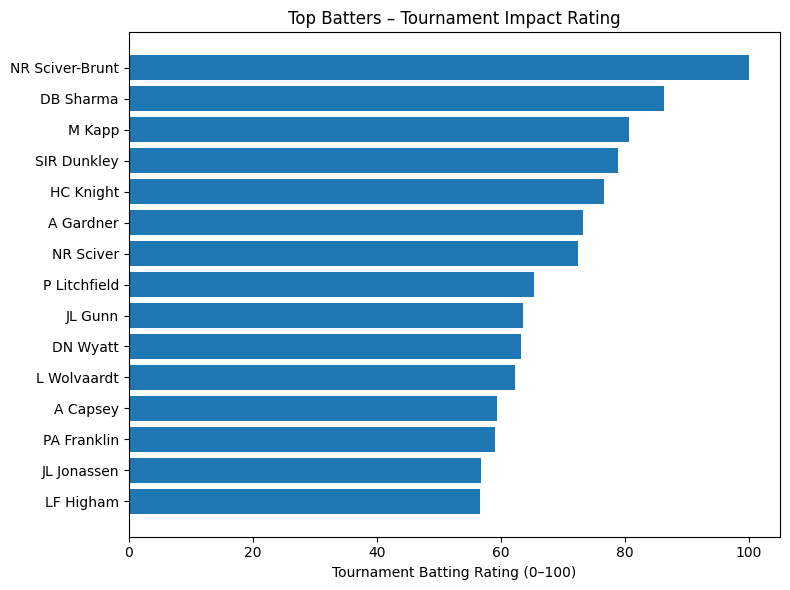

In [ ]:
import matplotlib.pyplot as plt

top_n = 15
top_batters = tournament_batting.sort_values(
    "Tournament_Rating_0_100",
    ascending=False
).head(top_n)

plt.figure(figsize=(8,6))
plt.barh(
    top_batters.index,
    top_batters["Tournament_Rating_0_100"]
)
plt.xlabel("Tournament Batting Rating (0–100)")
plt.title("Top Batters – Tournament Impact Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


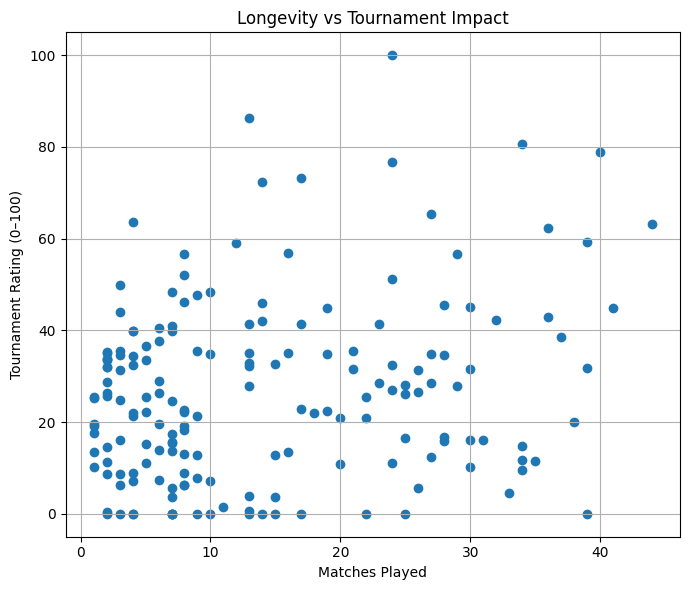

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(
    tournament_batting["Matches"],
    tournament_batting["Tournament_Rating_0_100"]
)

plt.xlabel("Matches Played")
plt.ylabel("Tournament Rating (0–100)")
plt.title("Longevity vs Tournament Impact")
plt.grid(True)
plt.tight_layout()
plt.show()


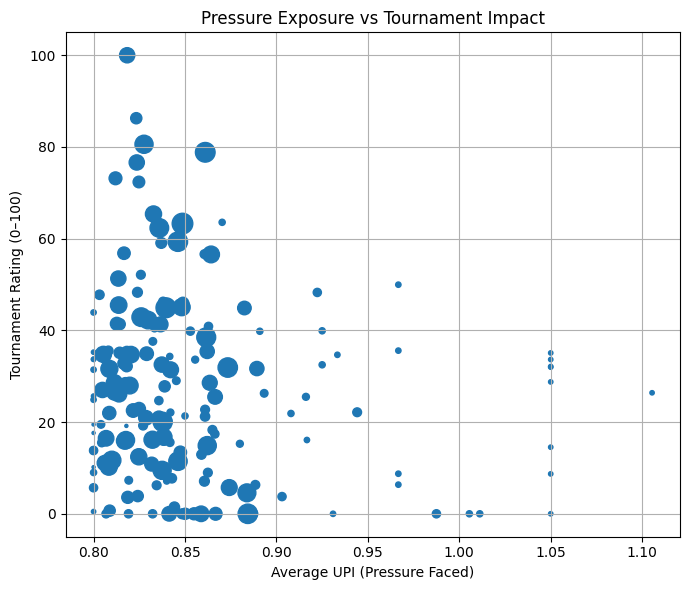

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(
    tournament_batting["Avg_UPI"],
    tournament_batting["Tournament_Rating_0_100"],
    s=tournament_batting["Matches"] * 5
)

plt.xlabel("Average UPI (Pressure Faced)")
plt.ylabel("Tournament Rating (0–100)")
plt.title("Pressure Exposure vs Tournament Impact")
plt.grid(True)
plt.tight_layout()
plt.show()


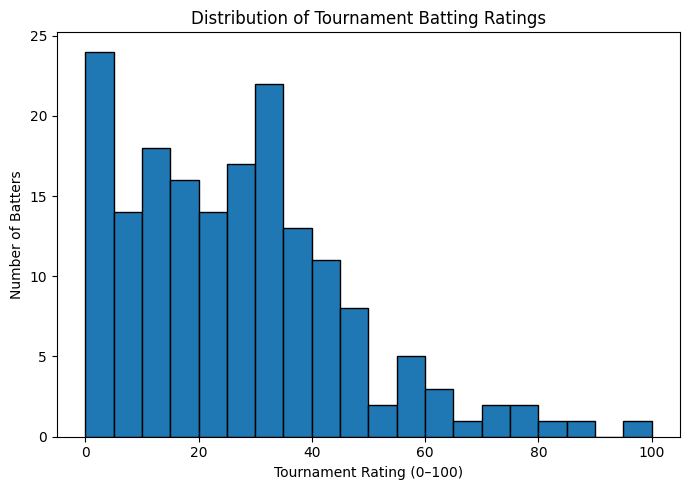

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(
    tournament_batting["Tournament_Rating_0_100"],
    bins=20,
    edgecolor="black"
)
plt.xlabel("Tournament Rating (0–100)")
plt.ylabel("Number of Batters")
plt.title("Distribution of Tournament Batting Ratings")
plt.tight_layout()
plt.show()


SECTION 3: BOWLING PERFORMANCE PIPELINE
The Hundred – Match & Tournament Level

 compute_match_bowling_rating() (Match-level, Hundred-aware)
🎯 Bowling philosophy
A good Hundred bowler:

takes high-impact wickets

creates dot-ball pressure

controls boundaries

performs under defend / chase pressure

bowls tough phases (death)

In [ ]:
def compute_match_bowling_rating(match_df):
    import numpy as np
    import pandas as pd

    df = match_df.copy()

    # ---------- Ball-level basics ----------
    df["total_runs"] = df["runs_off_bat"] + df["extras"]
    df["legal_ball"] = (
        df["wides"].isna() & df["noballs"].isna()
    ).astype(int)

    # ---------- Phase (Hundred) ----------
    def get_phase(ball):
        b = int(ball)
        if b <= 25:
            return "PP"
        elif b <= 80:
            return "Middle"
        else:
            return "Death"

    df["phase"] = df["ball"].apply(get_phase)

    # ---------- Wicket Impact Score (WIS) ----------
    df["is_wicket"] = df["player_dismissed"].notna().astype(int)

    wicket_weight = {"PP":1.2, "Middle":1.0, "Death":1.3}
    df["wicket_value"] = df["is_wicket"] * df["phase"].map(wicket_weight)

    WIS = df.groupby("bowler")["wicket_value"].sum()

    # ---------- Dot Ball Pressure (DBP) ----------
    df["dot_ball"] = (
        (df["total_runs"] == 0) &
        (df["legal_ball"] == 1)
    ).astype(int)

    dot_weight = {"PP":1.1, "Middle":1.0, "Death":1.3}
    df["dot_pressure"] = df["dot_ball"] * df["phase"].map(dot_weight)

    DBP = df.groupby("bowler")["dot_pressure"].sum()

    # ---------- Boundary Control Index (BCI) ----------
    df["is_boundary"] = df["runs_off_bat"].isin([4,6]).astype(int)

    boundary = df.groupby("bowler").agg(
        boundaries=("is_boundary","sum"),
        balls=("legal_ball","sum")
    )

    BCI = (1 - boundary["boundaries"] / boundary["balls"]).fillna(1)

    # ---------- Run Pressure Index (RPI) ----------
    match_rpb = df["total_runs"].sum() / df["legal_ball"].sum()

    bowler_runs = df.groupby("bowler")["total_runs"].sum()
    bowler_balls = df.groupby("bowler")["legal_ball"].sum()

    bowler_rpb = bowler_runs / bowler_balls
    RPI = (match_rpb - bowler_rpb) * bowler_balls

    # ---------- Death Overs Responsibility ----------
    death_balls = (
        df[df["phase"] == "Death"]
        .groupby("bowler")["legal_ball"]
        .sum()
    )

    DODB = (death_balls / bowler_balls).fillna(0)

    # ---------- Unified Bowling Pressure Index ----------
    df["current_rpb"] = (
        df.groupby("innings")["total_runs"].cumsum() /
        df.groupby("innings")["legal_ball"].cumsum()
    )

    df["UPI_bowl"] = np.where(
        df["innings"] == 2,
        df["current_rpb"] / match_rpb,            # defending pressure
        (match_rpb - df["current_rpb"]) / match_rpb  # attacking pressure
    ).clip(0.8, 1.3)

    Bowler_UPI = df.groupby("bowler")["UPI_bowl"].mean()

    # ---------- Base Bowling Rating ----------
    base_rating = (
        20 * WIS +
        15 * RPI +
        10 * DBP +
        10 * BCI +
        5  * DODB
    )

    final_rating = base_rating * Bowler_UPI

    # ---------- Normalize to 0–100 ----------
    min_r, max_r = final_rating.min(), final_rating.max()
    norm_rating = ((final_rating - min_r) / (max_r - min_r)) * 100

    return pd.DataFrame({
        "Bowling_Rating": norm_rating.round(1),
        "WIS": WIS,
        "DBP": DBP,
        "BCI": BCI,
        "RPI": RPI,
        "DODB": DODB,
        "UPI_bowl": Bowler_UPI
    })


 Run Bowling Pipeline for ALL Matches

In [ ]:
all_match_bowling = []

for match_id, match_df in tournament_df.groupby("match_file"):
    try:
        res = compute_match_bowling_rating(match_df)
        res["match_file"] = match_id
        res["season"] = match_df["season"].iloc[0]
        all_match_bowling.append(res)
    except Exception as e:
        print("Failed bowling:", match_id)


In [ ]:
match_level_bowling = (
    pd.concat(all_match_bowling)
    .reset_index()
    .rename(columns={"index":"bowler"})
)


 Tournament Bowling Rating + Consistency

In [ ]:
tournament_bowling = match_level_bowling.groupby("bowler").agg(
    Matches=("Bowling_Rating","count"),
    Avg_Rating=("Bowling_Rating","mean"),
    Std_Rating=("Bowling_Rating","std"),
    Avg_UPI=("UPI_bowl","mean"),
    Peak_Rating=("Bowling_Rating", lambda x: x.quantile(0.9))
).fillna(0)


Consistency & Experience

In [ ]:
import numpy as np

tournament_bowling["Consistency"] = (
    1 - (tournament_bowling["Std_Rating"] /
         tournament_bowling["Avg_Rating"])
).clip(0,1)

tournament_bowling["Experience"] = np.log1p(
    tournament_bowling["Matches"]
)


Final Tournament Bowling Score

In [ ]:
tournament_bowling["Tournament_Bowling_Score"] = (
    tournament_bowling["Avg_Rating"] *
    tournament_bowling["Consistency"] *
    tournament_bowling["Experience"]
)


Normalize (0–100)

In [ ]:
min_b, max_b = (
    tournament_bowling["Tournament_Bowling_Score"].min(),
    tournament_bowling["Tournament_Bowling_Score"].max()
)

tournament_bowling["Tournament_Rating_0_100"] = (
    (tournament_bowling["Tournament_Bowling_Score"] - min_b) /
    (max_b - min_b)
) * 100


Bowling Validation Visuals (Tournament Level)
Top Bowlers Leaderboard

In [ ]:
tournament_bowling.sort_values(
    "Tournament_Rating_0_100",
    ascending=False
).head(10)


,Matches,Avg_Rating,Std_Rating,Avg_UPI,Peak_Rating,Consistency,Experience,Tournament_Bowling_Score,Tournament_Rating_0_100
bowler,,,,,,,,,
M Kapp,34,71.885294,31.716224,0.894638,100.00,0.558794,3.555348,142.815025,100.000000
A Sutherland,24,63.320833,24.356358,0.862017,97.21,0.615350,3.218876,125.421809,87.821158
A Shrubsole,27,61.888889,24.686781,0.878593,92.80,0.601111,3.332205,123.965030,86.801112
S Ecclestone,34,63.370588,31.080126,0.882473,100.00,0.509550,3.555348,114.803831,80.386381
S Ismail,34,59.270588,27.046341,0.866949,96.22,0.543680,3.555348,114.568415,80.221541
LCN Smith,38,61.773684,30.970428,0.890764,100.00,0.498647,3.663562,112.849629,79.018036
KL Cross,41,57.656098,28.201073,0.878181,89.30,0.510874,3.737670,110.093150,77.087932
PJ Brett,2,100.000000,0.000000,1.001181,100.00,1.000000,1.098612,109.861229,76.925540
LK Bell,42,61.066667,33.798475,0.899279,100.00,0.446532,3.761200,102.561126,71.813960


Combine Batting + Bowling → Tournament MVP Index
🎯 MVP logic
An MVP contributes with both bat and ball.

In [ ]:
mvp_df = tournament_batting.merge(
    tournament_bowling,
    left_index=True,
    right_index=True,
    how="outer",
    suffixes=("_bat","_bowl")
).fillna(0)


MVP Score (Balanced)

In [ ]:
mvp_df["MVP_Score"] = (
    0.6 * mvp_df["Tournament_Rating_0_100_bat"] +
    0.4 * mvp_df["Tournament_Rating_0_100_bowl"]
)


Final MVP Ranking

In [ ]:
mvp_df["MVP_Score"] = (
    (mvp_df["MVP_Score"] - mvp_df["MVP_Score"].min()) /
    (mvp_df["MVP_Score"].max() - mvp_df["MVP_Score"].min())
) * 100

mvp_df.sort_values("MVP_Score", ascending=False).head(10)


,Matches_bat,Avg_Rating_bat,Std_Rating_bat,Avg_UPI_bat,Peak_Rating_bat,Consistency_bat,Experience_bat,Tournament_Batting_Score,Tournament_Rating_0_100_bat,Matches_bowl,Avg_Rating_bowl,Std_Rating_bowl,Avg_UPI_bowl,Peak_Rating_bowl,Consistency_bowl,Experience_bowl,Tournament_Bowling_Score,Tournament_Rating_0_100_bowl,MVP_Score
M Kapp,34.0,52.402941,31.993517,0.827585,100.00,0.389471,3.555348,72.562606,80.587241,34.0,71.885294,31.716224,0.894638,100.00,0.558794,3.555348,142.815025,100.000000,100.000000
DB Sharma,13.0,56.284615,26.850507,0.823342,85.36,0.522951,2.639057,77.678299,86.268673,17.0,65.264706,30.079165,0.857303,100.00,0.539120,2.890372,101.699293,71.210500,90.824306
NR Sciver-Brunt,24.0,65.837500,37.864286,0.818370,100.00,0.424883,3.218876,90.042301,100.000000,9.0,43.588889,29.432399,0.913167,85.32,0.324773,2.302585,32.596523,22.824295,78.243218
A Sutherland,24.0,47.066667,32.715661,0.813549,97.33,0.304908,3.218876,46.194104,51.302670,24.0,63.320833,24.356358,0.862017,97.21,0.615350,3.218876,125.421809,87.821158,74.599113
A Gardner,17.0,53.629412,30.836621,0.811981,100.00,0.425005,2.890372,65.879638,73.165210,17.0,51.364706,30.255122,0.907164,89.50,0.410974,2.890372,61.014544,42.722777,69.028430
S Ecclestone,28.0,36.953571,24.781960,0.813727,73.18,0.329376,3.367296,40.985416,45.517958,34.0,63.370588,31.080126,0.882473,100.00,0.509550,3.555348,114.803831,80.386381,67.304753
LCN Smith,13.0,30.053846,15.945617,0.814268,52.02,0.469432,2.639057,37.232426,41.349928,38.0,61.773684,30.970428,0.890764,100.00,0.498647,3.663562,112.849629,79.018036,63.854753
A Wellington,23.0,36.404348,24.697672,0.836622,54.12,0.321574,3.178054,37.204447,41.318855,41.0,55.892683,30.732771,0.899732,97.80,0.450147,3.737670,94.039440,65.847021,57.870701
SIR Dunkley,40.0,52.745000,33.629642,0.861073,100.00,0.362411,3.713572,70.986261,78.836569,8.0,37.112500,31.044596,0.927760,67.80,0.163500,2.197225,13.332547,9.335535,57.764348
LF Higham,8.0,41.312500,18.106150,0.860662,62.52,0.561727,2.197225,50.989562,56.628453,26.0,46.380769,28.514179,0.879795,87.85,0.385215,3.295837,58.885366,41.231912,57.123370


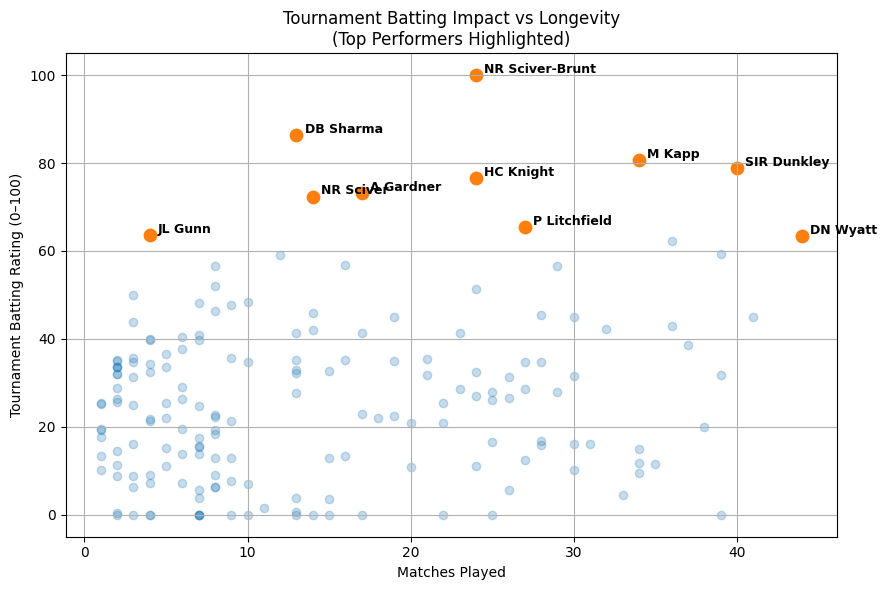

In [ ]:
import matplotlib.pyplot as plt

# Choose top batters to label
top_batters = tournament_batting.sort_values(
    "Tournament_Rating_0_100", ascending=False
).head(10)

plt.figure(figsize=(9,6))

# Background: all players
plt.scatter(
    tournament_batting["Matches"],
    tournament_batting["Tournament_Rating_0_100"],
    alpha=0.25
)

# Highlight: top batters
plt.scatter(
    top_batters["Matches"],
    top_batters["Tournament_Rating_0_100"],
    s=80
)

# Label only top batters
for batter in top_batters.index:
    plt.text(
        top_batters.loc[batter, "Matches"] + 0.5,
        top_batters.loc[batter, "Tournament_Rating_0_100"] + 0.5,
        batter,
        fontsize=9,
        weight="bold"
    )

plt.xlabel("Matches Played")
plt.ylabel("Tournament Batting Rating (0–100)")
plt.title("Tournament Batting Impact vs Longevity\n(Top Performers Highlighted)")
plt.grid(True)
plt.tight_layout()
plt.show()


 SOLUTION 2: Consistency vs Average (Elite Quadrant Only)

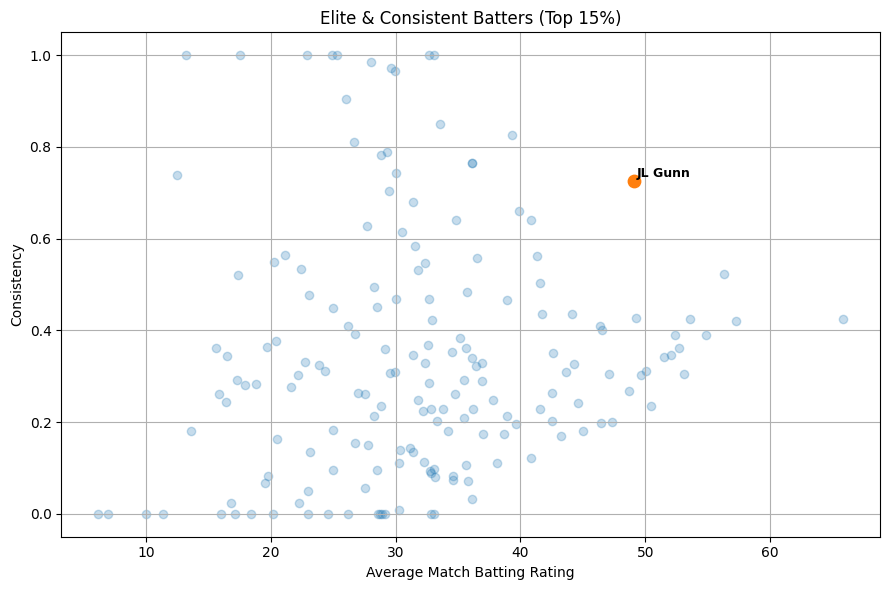

In [ ]:
top_consistent = tournament_batting[
    (tournament_batting["Avg_Rating"] > tournament_batting["Avg_Rating"].quantile(0.85)) &
    (tournament_batting["Consistency"] > tournament_batting["Consistency"].quantile(0.85))
]

plt.figure(figsize=(9,6))

# All players (context)
plt.scatter(
    tournament_batting["Avg_Rating"],
    tournament_batting["Consistency"],
    alpha=0.25
)

# Elite quadrant
plt.scatter(
    top_consistent["Avg_Rating"],
    top_consistent["Consistency"],
    s=80
)

for batter in top_consistent.index:
    plt.text(
        top_consistent.loc[batter, "Avg_Rating"] + 0.2,
        top_consistent.loc[batter, "Consistency"] + 0.01,
        batter,
        fontsize=9,
        weight="bold"
    )

plt.xlabel("Average Match Batting Rating")
plt.ylabel("Consistency")
plt.title("Elite & Consistent Batters (Top 15%)")
plt.grid(True)
plt.tight_layout()
plt.show()


SOLUTION 3: MVP Plot (Batting vs Bowling) — Clean & Powerful

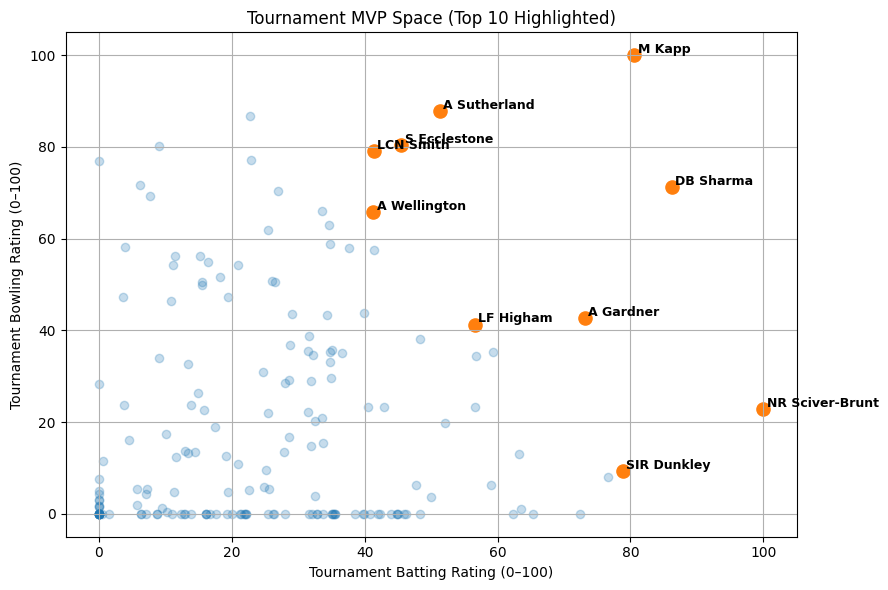

In [ ]:
top_mvp = mvp_df.sort_values("MVP_Score", ascending=False).head(10)

plt.figure(figsize=(9,6))

# Background
plt.scatter(
    mvp_df["Tournament_Rating_0_100_bat"],
    mvp_df["Tournament_Rating_0_100_bowl"],
    alpha=0.25
)

# Top MVPs
plt.scatter(
    top_mvp["Tournament_Rating_0_100_bat"],
    top_mvp["Tournament_Rating_0_100_bowl"],
    s=90
)

for player in top_mvp.index:
    plt.text(
        top_mvp.loc[player, "Tournament_Rating_0_100_bat"] + 0.5,
        top_mvp.loc[player, "Tournament_Rating_0_100_bowl"] + 0.5,
        player,
        fontsize=9,
        weight="bold"
    )

plt.xlabel("Tournament Batting Rating (0–100)")
plt.ylabel("Tournament Bowling Rating (0–100)")
plt.title("Tournament MVP Space (Top 10 Highlighted)")
plt.grid(True)
plt.tight_layout()
plt.show()


Bowling Longevity vs Tournament Impact
(Who sustained bowling impact over seasons?)

What this validates
Tournament rating is not just volume-driven



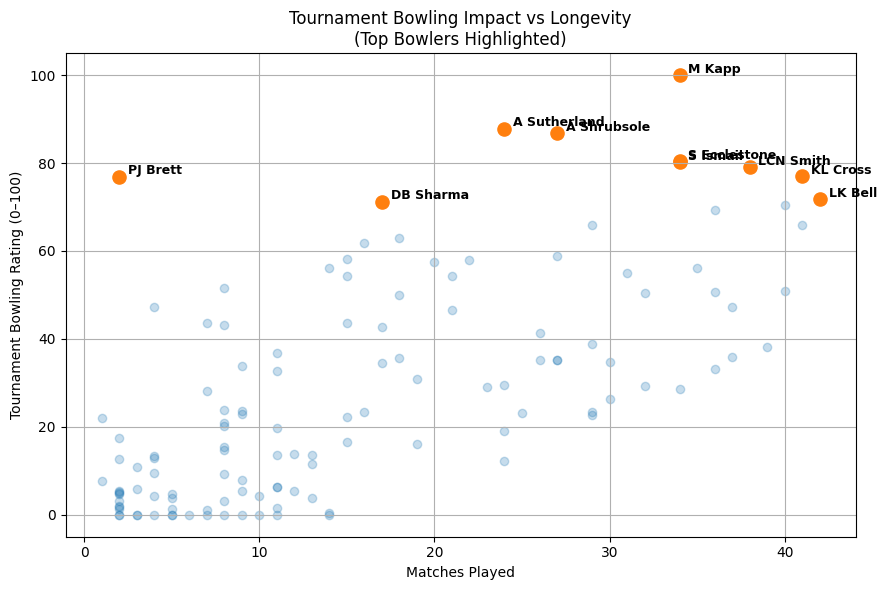

In [ ]:
import matplotlib.pyplot as plt

top_bowlers = tournament_bowling.sort_values(
    "Tournament_Rating_0_100", ascending=False
).head(10)

plt.figure(figsize=(9,6))

# Background: all bowlers
plt.scatter(
    tournament_bowling["Matches"],
    tournament_bowling["Tournament_Rating_0_100"],
    alpha=0.25
)

# Highlight: top bowlers
plt.scatter(
    top_bowlers["Matches"],
    top_bowlers["Tournament_Rating_0_100"],
    s=90
)

# Label top bowlers
for bowler in top_bowlers.index:
    plt.text(
        top_bowlers.loc[bowler, "Matches"] + 0.5,
        top_bowlers.loc[bowler, "Tournament_Rating_0_100"] + 0.5,
        bowler,
        fontsize=9,
        weight="bold"
    )

plt.xlabel("Matches Played")
plt.ylabel("Tournament Bowling Rating (0–100)")
plt.title("Tournament Bowling Impact vs Longevity\n(Top Bowlers Highlighted)")
plt.grid(True)
plt.tight_layout()
plt.show()


 How to read

Top-right → elite, long-term bowlers

High matches but low rating → durable but low impact

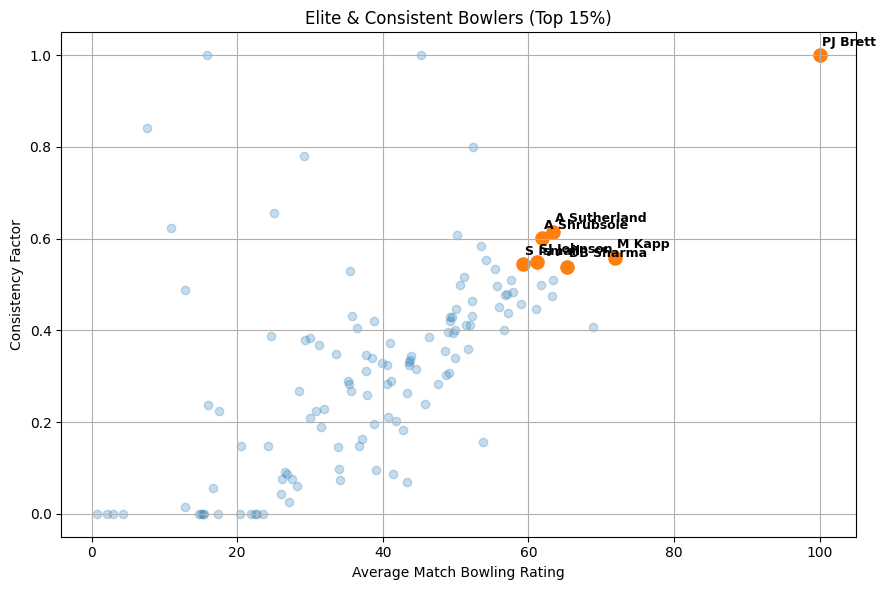

In [ ]:
top_consistent_bowlers = tournament_bowling[
    (tournament_bowling["Avg_Rating"] >
     tournament_bowling["Avg_Rating"].quantile(0.85)) &
    (tournament_bowling["Consistency"] >
     tournament_bowling["Consistency"].quantile(0.85))
]

plt.figure(figsize=(9,6))

# Background
plt.scatter(
    tournament_bowling["Avg_Rating"],
    tournament_bowling["Consistency"],
    alpha=0.25
)

# Elite consistent bowlers
plt.scatter(
    top_consistent_bowlers["Avg_Rating"],
    top_consistent_bowlers["Consistency"],
    s=90
)

for bowler in top_consistent_bowlers.index:
    plt.text(
        top_consistent_bowlers.loc[bowler, "Avg_Rating"] + 0.3,
        top_consistent_bowlers.loc[bowler, "Consistency"] + 0.02,
        bowler,
        fontsize=9,
        weight="bold"
    )

plt.xlabel("Average Match Bowling Rating")
plt.ylabel("Consistency Factor")
plt.title("Elite & Consistent Bowlers (Top 15%)")
plt.grid(True)
plt.tight_layout()
plt.show()


3️⃣ Pressure Handling vs Tournament Rating
(Who performs when it’s toughest?)

What this validates
Your UPI_bowl actually matters

High-pressure bowlers are rewarded

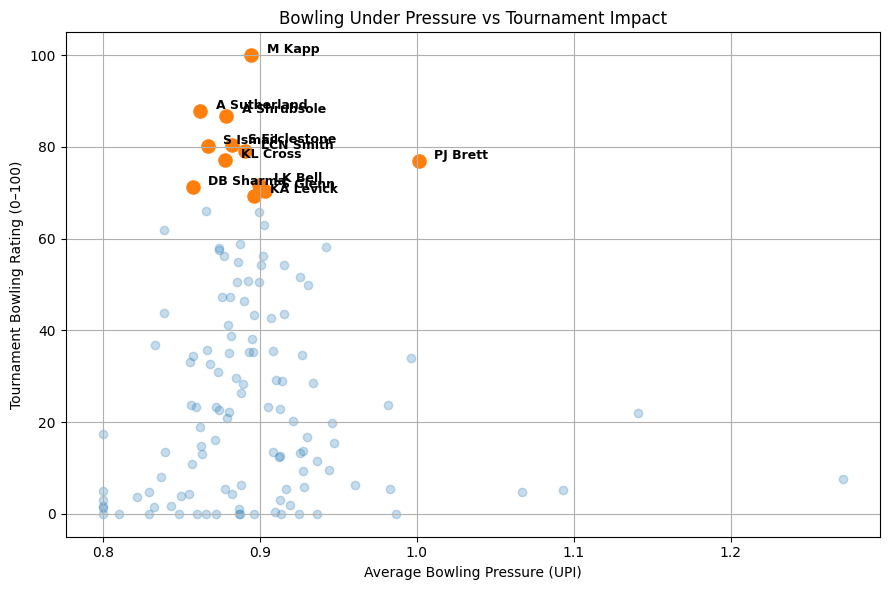

In [ ]:
top_pressure_bowlers = tournament_bowling.sort_values(
    "Tournament_Rating_0_100", ascending=False
).head(12)

plt.figure(figsize=(9,6))

# Background
plt.scatter(
    tournament_bowling["Avg_UPI"],
    tournament_bowling["Tournament_Rating_0_100"],
    alpha=0.25
)

# Highlight top bowlers
plt.scatter(
    top_pressure_bowlers["Avg_UPI"],
    top_pressure_bowlers["Tournament_Rating_0_100"],
    s=90
)

for bowler in top_pressure_bowlers.index:
    plt.text(
        top_pressure_bowlers.loc[bowler, "Avg_UPI"] + 0.01,
        top_pressure_bowlers.loc[bowler, "Tournament_Rating_0_100"] + 0.5,
        bowler,
        fontsize=9,
        weight="bold"
    )

plt.xlabel("Average Bowling Pressure (UPI)")
plt.ylabel("Tournament Bowling Rating (0–100)")
plt.title("Bowling Under Pressure vs Tournament Impact")
plt.grid(True)
plt.tight_layout()
plt.show()


 Interpretation

High UPI + high rating = clutch bowlers

Filters out flat-track specialists